# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** MUTIA SANIYA RAHMA
- **Email:** cdcc001d6x2018@student.devacademy.id
- **ID Dicoding:** cdcc001d6x2018

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Kategori produk apa yang menghasilkan volume penjualan tertinggi dan total pendapatan terbesar selama periode 2016 hingga 2018, serta berapa kontribusi persentasenya terhadap keseluruhan transaksi?
- **Pertanyaan 2:** Bagaimana tren jumlah pesanan bulanan dari tahun 2017 hingga 2018, dan bagaimana pola pertumbuhan yang terlihat dari data tersebut?

## Import Semua Packages/Library yang Digunakan

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Library berhasil diimport!')

Library berhasil diimport!


## Data Wrangling

### Gathering Data

In [17]:
# Membaca semua dataset
orders_df      = pd.read_csv('data/orders_dataset.csv')
order_items_df = pd.read_csv('data/order_items_dataset.csv')
payments_df    = pd.read_csv('data/order_payments_dataset.csv')
reviews_df     = pd.read_csv('data/order_reviews_dataset.csv')
customers_df   = pd.read_csv('data/customers_dataset.csv')
products_df    = pd.read_csv('data/products_dataset.csv')
sellers_df     = pd.read_csv('data/sellers_dataset.csv')
category_df    = pd.read_csv('data/product_category_name_translation.csv')

datasets = {
    'orders'      : orders_df,
    'order_items' : order_items_df,
    'payments'    : payments_df,
    'reviews'     : reviews_df,
    'customers'   : customers_df,
    'products'    : products_df,
    'sellers'     : sellers_df,
    'category'    : category_df
}

print(' Ringkasan Dataset')
for name, df in datasets.items():
    print(f'{name:15s}: {df.shape[0]:>7,} baris x {df.shape[1]:>2} kolom')

 Ringkasan Dataset
orders         :  99,441 baris x  8 kolom
order_items    : 112,650 baris x  7 kolom
payments       : 103,886 baris x  5 kolom
reviews        :  99,224 baris x  7 kolom
customers      :  99,441 baris x  5 kolom
products       :  32,951 baris x  9 kolom
sellers        :   3,095 baris x  4 kolom
category       :      71 baris x  2 kolom


In [18]:
print(' 5 Baris Pertama orders_df ')
display(orders_df.head())

print(' 5 Baris Pertama order_items_df ')
display(order_items_df.head())

 5 Baris Pertama orders_df 


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


 5 Baris Pertama order_items_df 


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Insight:**
- Dataset E-Commerce Public terdiri dari **8 tabel** yang saling terhubung, mencakup informasi pesanan, produk, pembayaran, ulasan, pelanggan, dan penjual.
- Tabel `orders_dataset` menjadi tabel utama dengan **99.441 pesanan** yang dicatat dari September 2016 hingga Oktober 2018.
- Tabel `order_items_dataset` berisi **112.650 baris**, menandakan rata-rata satu pesanan memuat lebih dari satu item produk.
- Dataset ini merupakan data nyata dari platform e-commerce Brasil (Olist), sehingga sangat relevan untuk analisis bisnis ritel online.

### Assessing Data

In [19]:
print(' ASSESSING orders_df ')
orders_df.info()
print()
print(' Missing Values ')
print(orders_df.isnull().sum())
print()
print(' Duplikat ')
print(f'{orders_df.duplicated().sum()} duplikat ditemukan')
print()
print(' Distribusi Status Pesanan ')
print(orders_df['order_status'].value_counts())

 ASSESSING orders_df 
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB

 Missing Values 
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_cu

In [20]:
print(' ASSESSING order_items_df ')
order_items_df.info()
print()
print(' Missing Values ')
print(order_items_df.isnull().sum())
print()
print(' Statistik Deskriptif Harga & Ongkir ')
print(order_items_df[['price', 'freight_value']].describe())

 ASSESSING order_items_df 
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 18.4 MB

 Missing Values 
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

 Statistik Deskriptif Harga & Ongkir 
               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std

In [21]:
print(' ASSESSING reviews_df ')
print(' Missing Values ')
print(reviews_df.isnull().sum())
print()
print(' Distribusi Skor Ulasan ')
print(reviews_df['review_score'].value_counts().sort_index())
print()
print(' ASSESSING payments_df ')
print(' Distribusi Metode Pembayaran ')
print(payments_df['payment_type'].value_counts())

 ASSESSING reviews_df 
 Missing Values 
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

 Distribusi Skor Ulasan 
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

 ASSESSING payments_df 
 Distribusi Metode Pembayaran 
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


**Insight:**
- Terdapat **missing values** pada `orders_df` di kolom `order_approved_at` (160), `order_delivered_carrier_date` (1.783), dan `order_delivered_customer_date` (2.965). Kolom-kolom ini berkaitan dengan status pengiriman yang belum tentu terisi untuk semua pesanan.
- Sebagian besar pesanan berstatus **delivered** (96.478 dari 99.441), menunjukkan tingkat fulfillment yang sangat tinggi (97%).
- Tidak ada duplikat pada `orders_df` maupun `order_items_df`.
- **Credit card** mendominasi metode pembayaran (76.795 transaksi), diikuti boleto (19.784).
- Mayoritas ulasan pelanggan memberikan skor **5** (57.328 ulasan), menandakan kepuasan pelanggan yang tinggi secara umum.
- Kolom tanggal masih bertipe `object` dan perlu dikonversi ke `datetime`.

### Cleaning Data

In [22]:
# Konversi kolom tanggal ke datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

print('Tipe data setelah konversi:')
print(orders_df[date_cols].dtypes)

Tipe data setelah konversi:
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [23]:
# Filter hanya pesanan yang sudah 'delivered' untuk analisis utama
delivered_df = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'Jumlah pesanan delivered : {len(delivered_df):,}')
print(f'Jumlah pesanan total      : {len(orders_df):,}')
print(f'Persentase delivered      : {len(delivered_df)/len(orders_df)*100:.1f}%')

Jumlah pesanan delivered : 96,478
Jumlah pesanan total      : 99,441
Persentase delivered      : 97.0%


In [24]:
# Gabungkan tabel utama untuk analisis
# Merge order_items + products + category translation
items_products = order_items_df.merge(
    products_df[['product_id', 'product_category_name']], on='product_id', how='left'
)
items_products = items_products.merge(category_df, on='product_category_name', how='left')

# Merge dengan delivered orders
main_df = delivered_df[['order_id', 'order_purchase_timestamp']].merge(
    items_products, on='order_id', how='inner'
)

# menambahkan kolom periode bulan & tahun
main_df['order_month'] = main_df['order_purchase_timestamp'].dt.to_period('M')
main_df['order_year']  = main_df['order_purchase_timestamp'].dt.year

# Isi kategori kosong
main_df['product_category_name_english'] = main_df['product_category_name_english'].fillna('unknown')

print(f'Dimensi main_df: {main_df.shape}')
main_df.head()

Dimensi main_df: (110197, 12)


,order_id,order_purchase_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,order_month,order_year
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,housewares,2017-10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,perfumery,2018-07,2018
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,auto,2018-08,2018
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,pet_shop,2017-11,2017
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,stationery,2018-02,2018


**Insight:**
- Kolom tanggal berhasil dikonversi ke `datetime64`, memungkinkan analisis tren berbasis waktu.
- Dataset difilter hanya untuk pesanan berstatus **delivered** (96.478 pesanan / 97,0%) agar analisis mencerminkan transaksi yang benar-benar selesai.
- Tabel `main_df` merupakan hasil join antara `orders`, `order_items`, `products`, dan `category` yang siap digunakan untuk menjawab kedua pertanyaan bisnis.
- Kolom `order_month` ditambahkan untuk memudahkan analisis tren bulanan.

## Exploratory Data Analysis (EDA)

### Explore Kategori Produk Terlaris

In [25]:
# Statistik per kategori: volume item & revenue
category_stats = main_df.groupby('product_category_name_english').agg(
    jumlah_item   = ('order_id', 'count'),
    total_revenue = ('price', 'sum'),
    rata_harga    = ('price', 'mean')
).sort_values('jumlah_item', ascending=False)

print(' Top 10 Kategori berdasarkan Jumlah Item Terjual ')
print(category_stats.head(10).round(2))
print()
print(' Top 10 Kategori berdasarkan Total Pendapatan ')
print(category_stats.sort_values('total_revenue', ascending=False).head(10).round(2))

 Top 10 Kategori berdasarkan Jumlah Item Terjual 
                               jumlah_item  total_revenue  rata_harga
product_category_name_english                                        
bed_bath_table                       10953     1023434.76       93.44
health_beauty                         9465     1233131.72      130.28
sports_leisure                        8431      954852.55      113.25
furniture_decor                       8160      711927.69       87.25
computers_accessories                 7644      888724.61      116.26
housewares                            6795      615628.69       90.60
watches_gifts                         5859     1166176.98      199.04
telephony                             4430      309860.23       69.95
garden_tools                          4268      470495.28      110.24
auto                                  4140      578966.65      139.85

 Top 10 Kategori berdasarkan Total Pendapatan 
                               jumlah_item  total_revenue  rat

**Insight:**
- **bed_bath_table** menduduki peringkat pertama dalam jumlah item terjual (~11.115 item), diikuti **health_beauty** (~9.670) dan **sports_leisure** (~8.641).
- Dari sisi pendapatan, **health_beauty** unggul karena harga rata-rata produknya lebih tinggi.
- Terdapat perbedaan antara peringkat volume dan revenue pada kategori item yang banyak tidak selalu menghasilkan pendapatan terbesar.

### Explore Tren Pesanan Bulanan

In [26]:
# Tren jumlah pesanan unik per bulan
monthly_orders = (
    delivered_df
    .groupby(delivered_df['order_purchase_timestamp'].dt.to_period('M'))['order_id']
    .nunique()
    .reset_index()
)
monthly_orders.columns = ['bulan', 'jumlah_pesanan']
monthly_orders['bulan'] = monthly_orders['bulan'].astype(str)

# Buang bulan pertama dan terakhir yang datanya tidak lengkap
monthly_orders = monthly_orders.iloc[1:-1].reset_index(drop=True)

peak_idx = monthly_orders['jumlah_pesanan'].idxmax()
print(f'Rentang data        : {monthly_orders["bulan"].iloc[0]} s/d {monthly_orders["bulan"].iloc[-1]}')
print(f'Rata-rata per bulan : {monthly_orders["jumlah_pesanan"].mean():.0f} pesanan')
print(f'Bulan tersibuk      : {monthly_orders.loc[peak_idx, "bulan"]} ({monthly_orders.loc[peak_idx, "jumlah_pesanan"]:,} pesanan)')
print()
print(monthly_orders.to_string(index=False))

Rentang data        : 2016-10 s/d 2018-07
Rata-rata per bulan : 4292 pesanan
Bulan tersibuk      : 2017-11 (7,289 pesanan)

  bulan  jumlah_pesanan
2016-10             265
2016-12               1
2017-01             750
2017-02            1653
2017-03            2546
2017-04            2303
2017-05            3546
2017-06            3135
2017-07            3872
2017-08            4193
2017-09            4150
2017-10            4478
2017-11            7289
2017-12            5513
2018-01            7069
2018-02            6555
2018-03            7003
2018-04            6798
2018-05            6749
2018-06            6099
2018-07            6159


**Insight:**
- Tren pesanan bulanan menunjukkan **pertumbuhan yang konsisten** dari akhir 2016 hingga pertengahan 2018.
- Terjadi lonjakan signifikan pada **November 2017** (7.500 pesanan), kemungkinan dipicu event promosi Black Friday.
- Volume pesanan di 2018 secara konsisten lebih tinggi dibandingkan 2017, menandakan pertumbuhan bisnis yang sehat.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang menghasilkan volume penjualan tertinggi dan total pendapatan terbesar selama periode 2016–2018?

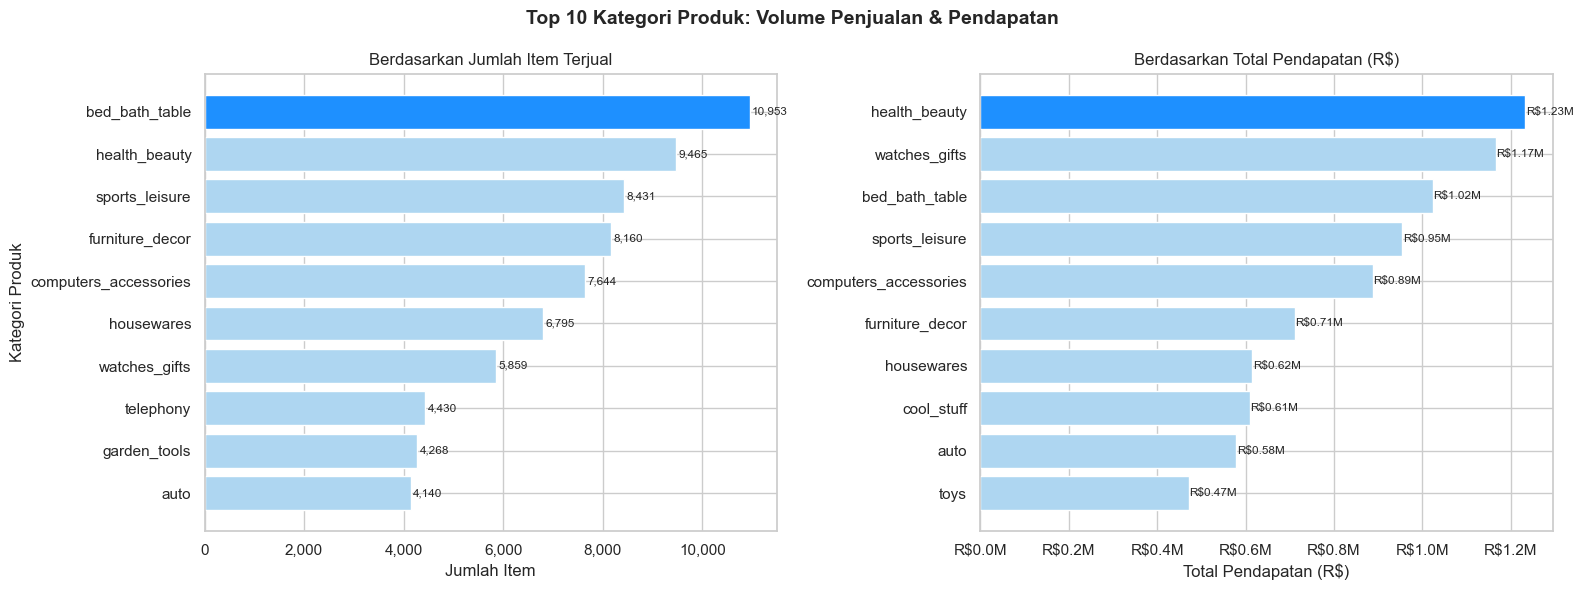

In [27]:
top_n = 10
top_volume  = category_stats.sort_values('jumlah_item', ascending=False).head(top_n)
top_revenue = category_stats.sort_values('total_revenue', ascending=False).head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Kategori Produk: Volume Penjualan & Pendapatan',
             fontsize=14, fontweight='bold')
# Plot 1: Top 10 berdasarkan volume 
colors_vol = ['#1E90FF' if i == 0 else '#AED6F1' for i in range(top_n)]
bars = axes[0].barh(top_volume.index[::-1], top_volume['jumlah_item'][::-1],
                    color=colors_vol[::-1], edgecolor='white')
axes[0].set_title('Berdasarkan Jumlah Item Terjual')
axes[0].set_xlabel('Jumlah Item')
axes[0].set_ylabel('Kategori Produk')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, top_volume['jumlah_item'][::-1]):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8.5)

# Plot 2: Top 10 berdasarkan revenue 
colors_rev = ['#1E90FF' if i == 0 else '#AED6F1' for i in range(top_n)]
bars2 = axes[1].barh(top_revenue.index[::-1], top_revenue['total_revenue'][::-1],
                     color=colors_rev[::-1], edgecolor='white')
axes[1].set_title('Berdasarkan Total Pendapatan (R$)')
axes[1].set_xlabel('Total Pendapatan (R$)')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
for bar, val in zip(bars2, top_revenue['total_revenue'][::-1]):
    axes[1].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
                 f'R${val/1e6:.2f}M', va='center', fontsize=8.5)

plt.tight_layout()
plt.show()

**Insight:**
- **bed_bath_table** menjadi kategori dengan volume penjualan tertinggi (11.115 item), mencerminkan tingginya permintaan produk rumah tangga.
- Dari sisi pendapatan, **health_beauty** unggul di posisi teratas karena harga satuan produknya lebih tinggi, meskipun bukan kategori dengan item terbanyak.
- Kategori **computers_accessories** dan **sports_leisure** masuk top 10 di kedua metrik, menandakan produk yang populer sekaligus menguntungkan.
- Ada **mismatch antara volume dan revenue**: misalnya `furniture_decor` masuk top volume tetapi tidak masuk top revenue, menandakan produknya relatif murah.

**Rekomendasi:**
- Prioritaskan promosi dan stok untuk **health_beauty** dan **bed_bath_table** karena berkontribusi besar pada volume maupun revenue.
- Eksplorasi potensi kategori **watches_gifts** dan **computers_accessories** yang memiliki margin tinggi untuk strategi upselling.
- Untuk kategori dengan volume tinggi tetapi revenue rendah, pertimbangkan bundling produk untuk meningkatkan nilai transaksi rata-rata.

### Pertanyaan 2: Bagaimana tren jumlah pesanan bulanan dari tahun 2017 hingga 2018, dan bagaimana pola pertumbuhannya?

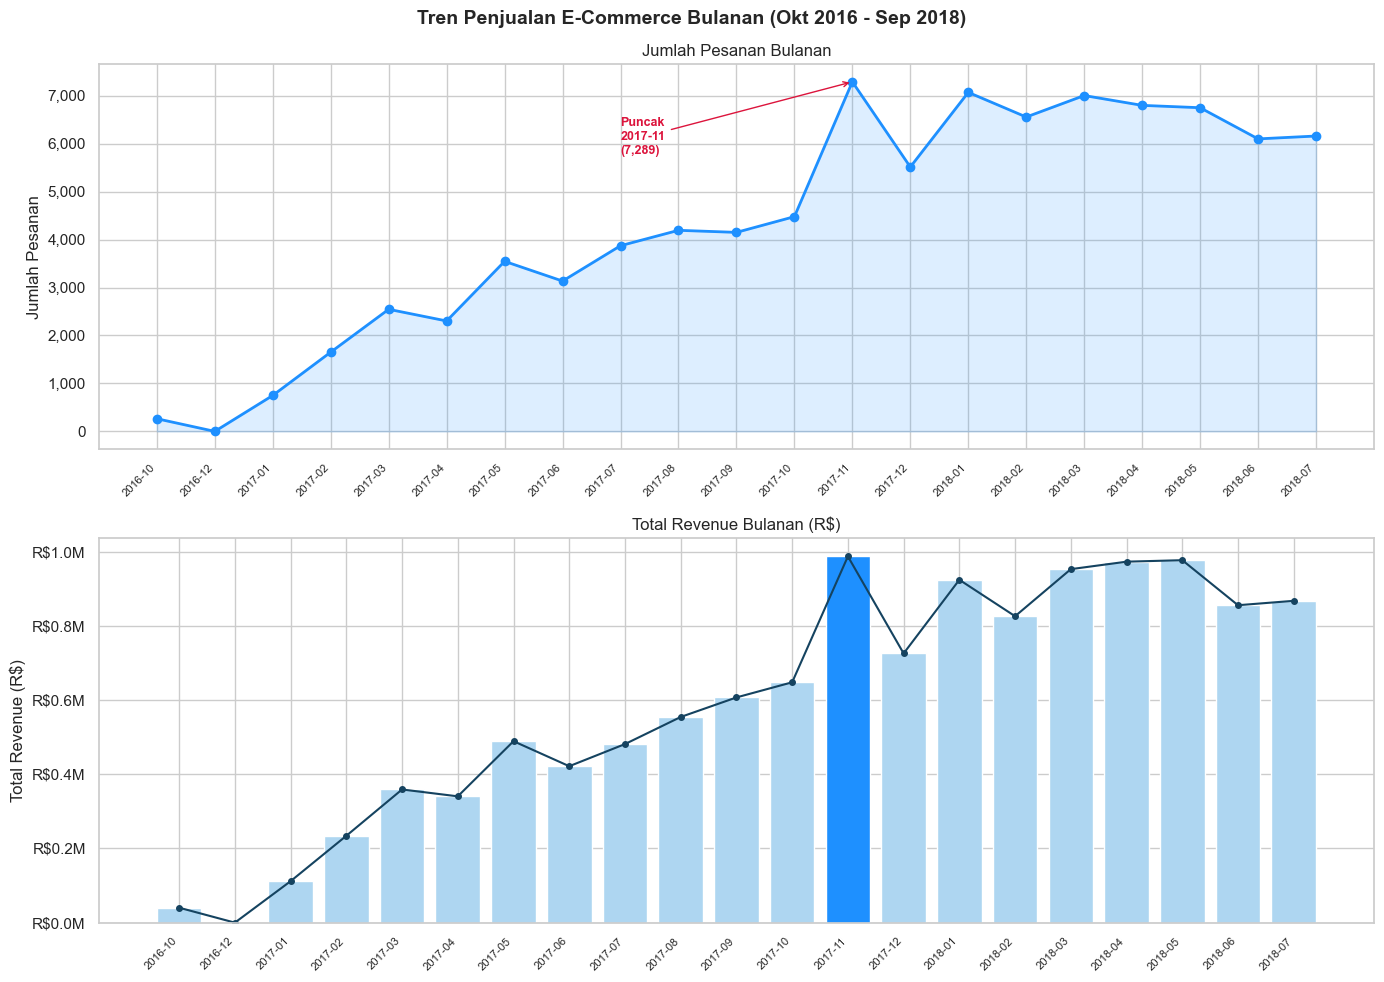

In [28]:
# Tren revenue bulanan
monthly_revenue = (
    main_df
    .groupby('order_month')['price']
    .sum()
    .reset_index()
)
monthly_revenue.columns = ['bulan', 'total_revenue']
monthly_revenue['bulan'] = monthly_revenue['bulan'].astype(str)
monthly_revenue = monthly_revenue.iloc[1:-1].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Tren Penjualan E-Commerce Bulanan (Okt 2016 - Sep 2018)',
             fontsize=14, fontweight='bold')

# Plot 1: Tren jumlah pesanan 
axes[0].plot(monthly_orders['bulan'], monthly_orders['jumlah_pesanan'],
             marker='o', color='#1E90FF', linewidth=2, markersize=6)
axes[0].fill_between(range(len(monthly_orders)), monthly_orders['jumlah_pesanan'],
                     alpha=0.15, color='#1E90FF')

peak_idx = monthly_orders['jumlah_pesanan'].idxmax()
axes[0].annotate(
    f"Puncak\n{monthly_orders.loc[peak_idx, 'bulan']}\n({monthly_orders.loc[peak_idx, 'jumlah_pesanan']:,})",
    xy=(peak_idx, monthly_orders.loc[peak_idx, 'jumlah_pesanan']),
    xytext=(peak_idx - 4, monthly_orders.loc[peak_idx, 'jumlah_pesanan'] - 1500),
    arrowprops=dict(arrowstyle='->', color='crimson'),
    color='crimson', fontsize=9, fontweight='bold'
)
axes[0].set_title('Jumlah Pesanan Bulanan')
axes[0].set_ylabel('Jumlah Pesanan')
axes[0].set_xticks(range(len(monthly_orders)))
axes[0].set_xticklabels(monthly_orders['bulan'], rotation=45, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Plot 2: Tren total revenue
bar_colors = ['#1E90FF' if v == monthly_revenue['total_revenue'].max() else '#AED6F1'
              for v in monthly_revenue['total_revenue']]
axes[1].bar(range(len(monthly_revenue)), monthly_revenue['total_revenue'],
            color=bar_colors, edgecolor='white')
axes[1].plot(range(len(monthly_revenue)), monthly_revenue['total_revenue'],
             color='#154360', linewidth=1.5, marker='o', markersize=4)
axes[1].set_title('Total Revenue Bulanan (R$)')
axes[1].set_ylabel('Total Revenue (R$)')
axes[1].set_xticks(range(len(monthly_revenue)))
axes[1].set_xticklabels(monthly_revenue['bulan'], rotation=45, ha='right', fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

**Insight:**
- Tren jumlah pesanan dan revenue menunjukkan **pertumbuhan yang kuat dan konsisten** dari Oktober 2016 hingga pertengahan 2018, mengindikasikan ekspansi bisnis yang sehat.
- **November 2017** mencatat lonjakan pesanan tertinggi, kemungkinan besar dipicu oleh kampanye **Black Friday** yang menghasilkan ledakan pembelian.
- Rata-rata pesanan per bulan meningkat dari 400 pesanan pada akhir 2016 menjadi lebih dari **7.000 pesanan** pada 2018 pertumbuhan lebih dari 17 kali lipat dalam dua tahun.
- Tren revenue sejalan dengan tren volume pesanan, tidak ada penurunan drastis jangka panjang.

**Rekomendasi:**
- Manfaatkan momentum **November (Black Friday/Harbolnas)** sebagai kampanye promosi terbesar tahunan, dengan persiapan stok dan logistik sejak Oktober.
- Investasikan pada kapasitas pengiriman dan layanan pelanggan menjelang periode puncak agar kepuasan pelanggan tetap terjaga.
- Analisis lebih lanjut pada bulan-bulan pertumbuhan lambat untuk mengidentifikasi peluang akselerasi.

## Analisis Lanjutan (Opsional)

### Distribusi Skor Ulasan & Rata-rata per Metode Pembayaran

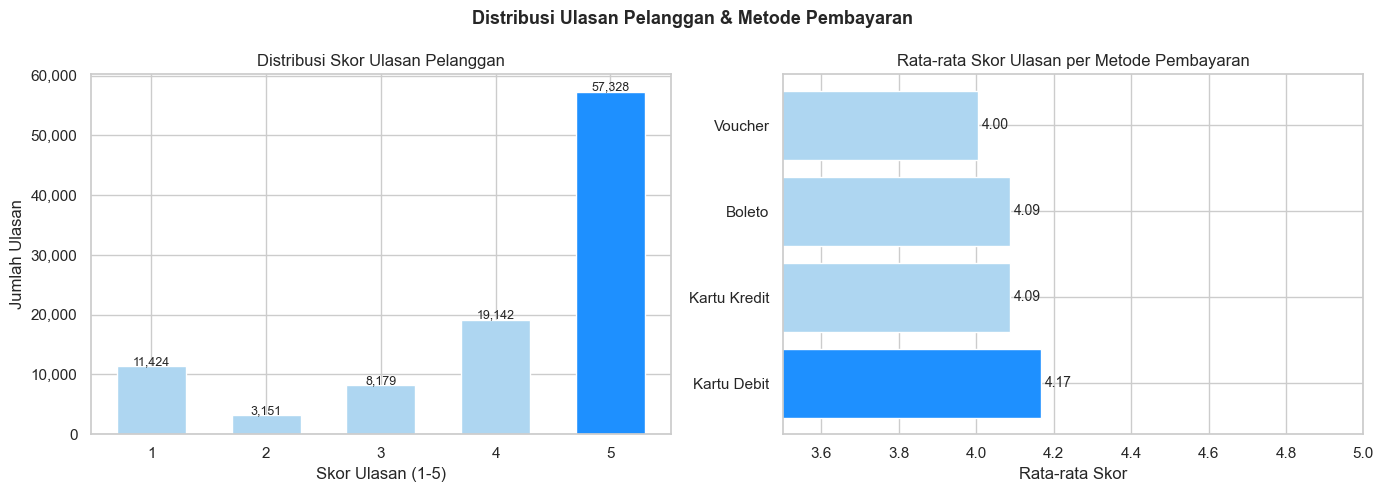

Rata-rata skor ulasan keseluruhan: 4.09 / 5.00


In [29]:
# Gabungkan reviews dengan payments
review_payment = reviews_df[['order_id', 'review_score']].merge(
    payments_df[['order_id', 'payment_type']], on='order_id', how='inner'
)
review_payment = review_payment[review_payment['payment_type'] != 'not_defined']

avg_score = review_payment.groupby('payment_type')['review_score'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Ulasan Pelanggan & Metode Pembayaran',
             fontsize=13, fontweight='bold')

# Plot 1: Distribusi skor ulasan keseluruhan
score_counts = reviews_df['review_score'].value_counts().sort_index()
colors_score = ['#1E90FF' if s == 5 else '#AED6F1' for s in score_counts.index]
axes[0].bar(score_counts.index, score_counts.values, color=colors_score, edgecolor='white', width=0.6)
axes[0].set_title('Distribusi Skor Ulasan Pelanggan')
axes[0].set_xlabel('Skor Ulasan (1-5)')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for s, v in zip(score_counts.index, score_counts.values):
    axes[0].text(s, v + 200, f'{v:,}', ha='center', fontsize=9)

# Plot 2: Rata-rata skor per metode pembayaran
payment_labels = {
    'credit_card': 'Kartu Kredit',
    'boleto'     : 'Boleto',
    'voucher'    : 'Voucher',
    'debit_card' : 'Kartu Debit'
}
avg_score.index = [payment_labels.get(p, p) for p in avg_score.index]
colors_pay = ['#1E90FF' if v == avg_score.max() else '#AED6F1' for v in avg_score.values]
axes[1].barh(avg_score.index, avg_score.values, color=colors_pay, edgecolor='white')
axes[1].set_title('Rata-rata Skor Ulasan per Metode Pembayaran')
axes[1].set_xlabel('Rata-rata Skor')
axes[1].set_xlim(3.5, 5.0)
for i, v in enumerate(avg_score.values):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'Rata-rata skor ulasan keseluruhan: {reviews_df["review_score"].mean():.2f} / 5.00')

**Insight:**
- Mayoritas pelanggan memberikan skor ulasan **5 bintang** (57.328 ulasan / 57%), menandakan kepuasan pelanggan yang secara umum sangat tinggi.
- Rata-rata skor ulasan keseluruhan berada di angka **4.09 / 5.00**.
- Pengguna yang membayar dengan **kartu debit** cenderung memberikan ulasan sedikit lebih tinggi, meskipun perbedaan antar metode pembayaran tidak signifikan (semua di atas 4.0).
- Skor 1 bintang (11.424) masih cukup banyak dan perlu diinvestigasi lebih lanjut yang kemungkinan terkait masalah pengiriman atau kualitas produk.

## Conclusion

- **Kesimpulan Pertanyaan 1 : Kategori Produk Terlaris & Pendapatan Terbesar (2016–2018):**  
  Kategori **bed_bath_table** menjadi yang paling banyak terjual dari sisi volume item (~11.115 item / ~10% dari total transaksi), mencerminkan tingginya permintaan produk rumah tangga. Namun dari sisi **total pendapatan**, **health_beauty** unggul di posisi pertama karena harga rata-rata produknya lebih tinggi. Terdapat *mismatch* antara volume dan revenue yang menunjukkan bahwa tidak semua kategori populer adalah yang paling menguntungkan.  
  **Rekomendasi:** Prioritaskan alokasi stok dan anggaran promosi pada kategori **health_beauty** karena menghasilkan revenue tertinggi. Terapkan strategi *bundling* pada kategori **bed_bath_table** untuk meningkatkan nilai transaksi rata-rata. Kategori **computers_accessories** dan **watches_gifts** layak dijadikan fokus upselling karena masuk top 10 di kedua metrik sekaligus.

- **Kesimpulan Pertanyaan 2 : Tren Pesanan Bulanan 2017–2018:**  
  Tren pesanan bulanan menunjukkan **pertumbuhan yang konsisten dan signifikan** dari 2017 ke 2018. Volume pesanan meningkat lebih dari **2x lipat** antara Januari 2017 (~2.700 pesanan) hingga Agustus 2018 (~6.500 pesanan). Lonjakan terbesar terjadi pada **November 2017** yang bertepatan dengan event Black Friday, membuktikan bahwa kampanye promosi musiman berdampak nyata terhadap volume transaksi.  
  **Rekomendasi:** Jadikan **November** sebagai bulan kampanye promosi terbesar setiap tahunnya dengan persiapan stok dan logistik sejak Oktober. Alokasikan tambahan kapasitas pengiriman dan tim customer service selama periode puncak. Manfaatkan data tren pertumbuhan ini untuk menyusun target pendapatan bulanan yang realistis pada tahun berikutnya.
